In [15]:
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.RobotController import RobotController
from optimal.configuration import UR10
import optimal.metrics as metrics
import numpy as np

MAX_ERROR_DEG = 0.5  # hard ceiling on the position error
type = UR10
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

def objective(trial, DT, path, interpolate = False):
    # Ask Optuna to guess the weights (we use log scale because weights can vary wildly)
    kp1 = trial.suggest_float("kp1", 1, 2e3, log=True)
    kp2 = trial.suggest_float("kp2", 1, 2e3, log=True)
    kp3 = trial.suggest_float("kp3", 1, 2e3, log=True)
    kp4 = trial.suggest_float("kp4", 1, 50, log=True)
    kp5 = trial.suggest_float("kp5", 1, 50, log=True)
    kp6 = trial.suggest_float("kp6", 1, 50, log=True)
    ratio1 = trial.suggest_float("ratio1", 0.05, 0.15)
    ratio2 = trial.suggest_float("ratio2", 0.05, 0.15)
    ratio3 = trial.suggest_float("ratio3", 0.05, 0.15)
    ratio4 = trial.suggest_float("ratio4", 0.05, 0.15)
    ratio5 = trial.suggest_float("ratio5", 0.05, 0.15)
    ratio6 = trial.suggest_float("ratio6", 0.05, 0.15)
    # time_limit    = trial.suggest_int("time_limit",        500, 1500, log=True)
    time_limit = 1000
    if interpolate:
        alpha = trial.suggest_float("alpha", 0, 1)
        interpolation_method = trial.suggest_categorical("interpolation_method", ["linear", "trapezoidal", "cubic", "quintic"])
    else:
        alpha = 0
        interpolation_method = "linear"

    # kp_body       = trial.suggest_float("kp_body",       1, 5e3,  log=True)
    # kp_wrist      = trial.suggest_float("kp_wrist",      1, 500,  log=True)
    # body_ratio  = trial.suggest_float("body_ratio", 0.01, 0.3)
    # wrist_ratio = trial.suggest_float("wrist_ratio", 0.01, 0.3)

    # Calculate Kd based on Kp and the guessed ratio
    kd1 = kp1 * ratio1
    kd2 = kp2 * ratio2
    kd3 = kp3 * ratio3
    kd4 = kp4 * ratio4
    kd5 = kp5 * ratio5
    kd6 = kp6 * ratio6
    # kd_body  = kp_body * body_ratio
    # kd_wrist = kp_wrist * wrist_ratio

    # kp = np.array([kp_body]*3 + [kp_wrist]*3)
    # kd = np.array([kd_body]*3 + [kd_wrist]*3)

    kp = np.array([kp1, kp2, kp3, kp4, kp5, kp6])
    kd = np.array([kd1, kd2, kd3, kd4, kd5, kd6])

    # Initialize your controller
    controller = RobotController(robot_pin_model)
    xs, us = [], []   
    
    try:
        nq = len(robot_pin_model.q_indices)
        nv = len(robot_pin_model.v_indices)
        current_q = path[0]
        current_v = np.zeros(nv)
        last_u = np.zeros(nv)
        
        for i in range(1, len(path)):
            target_q = path[i]
            x_start = np.concatenate([current_q, current_v])
            x_goal  = np.concatenate([target_q, np.zeros(nv)])
            
            t_xs, t_us = controller.compute_control(x_start=x_start, 
                                                    x_goal=x_goal, 
                                                    T=time_limit, DT=DT, kp=kp, kd=kd,
                                                    alpha=alpha, 
                                                    interpolation=interpolation_method,
                                                    option="pd")
            
            actual_q = t_xs[-1][:nq]
            actual_v = t_xs[-1][nq:]
            
            xs.extend(t_xs)
            us.extend(t_us)
            current_q = actual_q
            current_v = actual_v
            last_u = t_us[-1]
            
    except Exception as e:
        # If the solver crashes (e.g. weights were numerically unstable), 
        # return a massive penalty so Optuna knows it was a bad guess.
        print(f"Solver failed with error: {e}")
        return float('inf')

    prec_deg = metrics.tracking_error(xs, path[1:], [time_limit] * (len(path) - 1))
    metric_score = metrics.unified_cost(us, xs, DT, path[1:], [time_limit] * (len(path) - 1))
    if prec_deg > MAX_ERROR_DEG:
        metric_score += 1e9 * (prec_deg - MAX_ERROR_DEG)  # hard precision barrier
    # If the score is NaN (diverged), penalize it
    if np.isnan(metric_score):
        return float('inf')
        
    return metric_score


## One set of Params for entire trajectory

In [16]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

DT = robot_mj_model.model.opt.timestep
path = [robot_pin_model.current_q(),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([0.4, -0.4, 1.5, -0.8, 1.5, 0.5])]

# === Approach 1: Globally tune weights for the entire path ===
study = optuna.create_study(direction="minimize")
# 100 trials is a relatively good start for tuning 5 hyperparameters
study.optimize(lambda trial: objective(trial, DT, path, interpolate=True), n_trials=500, show_progress_bar=True)

print("Best global parameters:", study.best_params)
print("Best global score:", study.best_value)

# Duplicate parameters for each segment so later code can just use params[i]
params = [study.best_params for _ in range(len(path) - 1)]
# non_interpolate_params = {'kp1': 361.294563854303, 'kp2': 293.52745335780975, 'kp3': 228.2296033611799, 'kp4': 22.690948569115832, 'kp5': 13.07005198773434, 'kp6': 2.5984088230558693, 'ratio1': 0.10479072652427698, 'ratio2': 0.12781582477315725, 'ratio3': 0.12335036969297616, 'ratio4': 0.06478796345284489, 'ratio5': 0.05312662904079803, 'ratio6': 0.09456669853752082}


Best trial: 371. Best value: 21355.9: 100%|██████████| 500/500 [01:05<00:00,  7.62it/s] 

Best global parameters: {'kp1': 1298.660262054322, 'kp2': 1985.318782944338, 'kp3': 575.3780810829126, 'kp4': 11.307946427755194, 'kp5': 7.913408265869875, 'kp6': 6.483807265310681, 'ratio1': 0.11002402832547768, 'ratio2': 0.09414418180371176, 'ratio3': 0.1303759111003449, 'ratio4': 0.08914155640404342, 'ratio5': 0.11913043749380875, 'ratio6': 0.05008873930079517, 'alpha': 0.9277063999832136, 'interpolation_method': 'quintic'}
Best global score: 21355.85641755079


## Individual sets of Params per segment

In [83]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

DT = robot_mj_model.model.opt.timestep
path = [robot_pin_model.current_q(),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([0.4, -0.4, 1.5, -0.8, 1.5, 0.5])]

# === Approach 2: Tune weights for each segment individually ===
# (Useful if some movements are short/precise and others are long sweeps)

params_per_segment = []
current_q = path[0]

for i in range(1, len(path)):
    print(f"--- Evaluating Path Segment {i}/{len(path)-1} ---")
    study = optuna.create_study(direction="minimize")
    
    # We create a sub-path of just the start (current_q) and target (path[i]).
    sub_path = [current_q, path[i]]
    func = lambda trial: objective(trial, DT, sub_path)
    
    study.optimize(func, n_trials=100, show_progress_bar=True)
    params_per_segment.append(study.best_params)
    print(f"Best score for segment {i}: {study.best_value}")
    
    # We assume the tuner successfully reaches the target (or very close),
    # so the next segment starts from the target position.
    current_q = path[i]

print("\n=== All Best Coefficients (Per Segment) ===")
for i, param in enumerate(params_per_segment):
    print(f"Segment {i+1}: {param}")

params = params_per_segment

# Uncomment below if you want the subsequent simulation cells to use per-segment params
# params = params_per_segment

--- Evaluating Path Segment 1/4 ---


Best trial: 97. Best value: 5.54165e+06: 100%|██████████| 100/100 [00:06<00:00, 16.62it/s]


Best score for segment 1: 5541650.971029315
--- Evaluating Path Segment 2/4 ---


Best trial: 37. Best value: 2.27103e+06: 100%|██████████| 100/100 [00:03<00:00, 27.46it/s]


Best score for segment 2: 2271025.1698534484
--- Evaluating Path Segment 3/4 ---


Best trial: 81. Best value: 2.52061e+06: 100%|██████████| 100/100 [00:03<00:00, 28.14it/s]


Best score for segment 3: 2520614.5524950656
--- Evaluating Path Segment 4/4 ---


Best trial: 55. Best value: 7.01864e+06: 100%|██████████| 100/100 [00:03<00:00, 32.71it/s]

Best score for segment 4: 7018639.916591622

=== All Best Coefficients (Per Segment) ===
Segment 1: {'kp_body': 124.59758676172618, 'kp_wrist': 1.1877930561976169, 'time_limit': 1470, 'body_ratio': 0.15677671232875545, 'wrist_ratio': 0.1349556653597779}
Segment 2: {'kp_body': 177.08421960472145, 'kp_wrist': 2.359282519578757, 'time_limit': 1088, 'body_ratio': 0.1399808933154336, 'wrist_ratio': 0.06197674783732858}
Segment 3: {'kp_body': 122.92261749019849, 'kp_wrist': 2.237721102951794, 'time_limit': 1219, 'body_ratio': 0.1846415932949908, 'wrist_ratio': 0.10850795167937172}
Segment 4: {'kp_body': 136.08457858158175, 'kp_wrist': 28.777381289325707, 'time_limit': 830, 'body_ratio': 0.29468370381175735, 'wrist_ratio': 0.010184232882793883}


## CMA-ES SAMPLER

In [10]:
import optuna
from optuna.samplers import CmaEsSampler
from optimal.configuration import Trajectories
optuna.logging.set_verbosity(optuna.logging.WARNING)

DT = robot_mj_model.model.opt.timestep
path = Trajectories.joint_6dof

# === Approach 1: Globally tune weights for the entire path ===
study = optuna.create_study(direction="minimize", sampler=CmaEsSampler())
# 100 trials is a relatively good start for tuning 5 hyperparameters
study.optimize(lambda trial: objective(trial, DT, path), n_trials=500, show_progress_bar=True)

print("Best global parameters:", study.best_params)
print("Best global score:", study.best_value)

# Duplicate parameters for each segment so later code can just use params[i]
params = [study.best_params for _ in range(len(path) - 1)]

Best trial: 494. Best value: 2.45993e+07: 100%|██████████| 500/500 [00:45<00:00, 11.02it/s]

Best global parameters: {'kp1': 196.7877552472155, 'kp2': 179.30380743357395, 'kp3': 231.79183951506678, 'kp4': 32.15909504109984, 'kp5': 6.993739397504744, 'kp6': 3.8927540741719517, 'ratio1': 0.1391880079327345, 'ratio2': 0.1467813082752683, 'ratio3': 0.13345356440319028, 'ratio4': 0.1268657221983308, 'ratio5': 0.09674055422918852, 'ratio6': 0.09605100985601961}
Best global score: 24599305.514134176


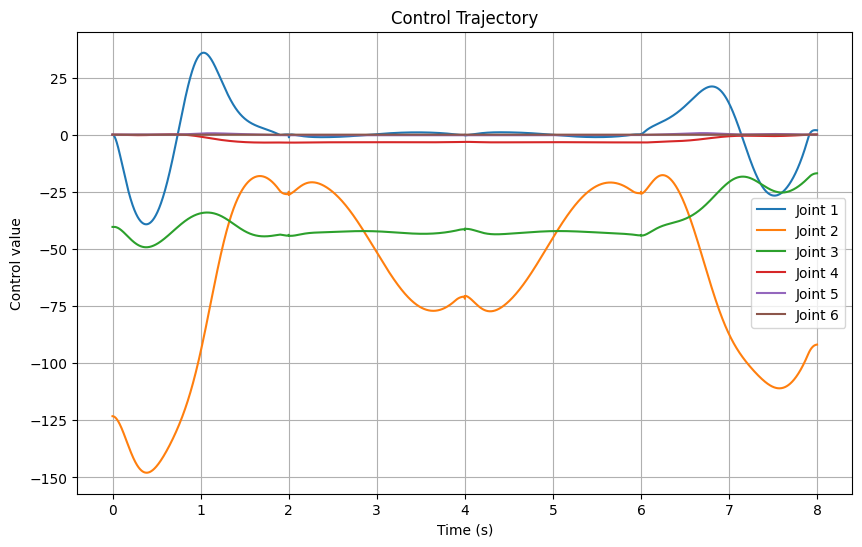

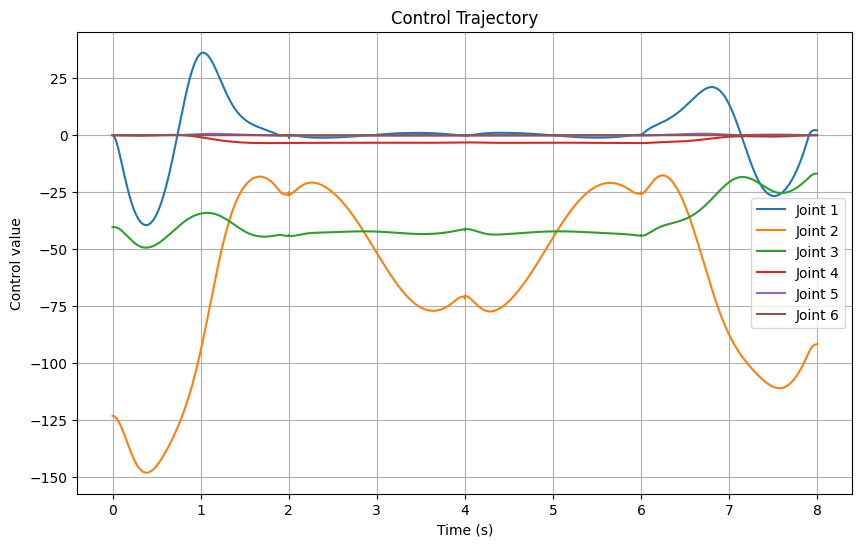

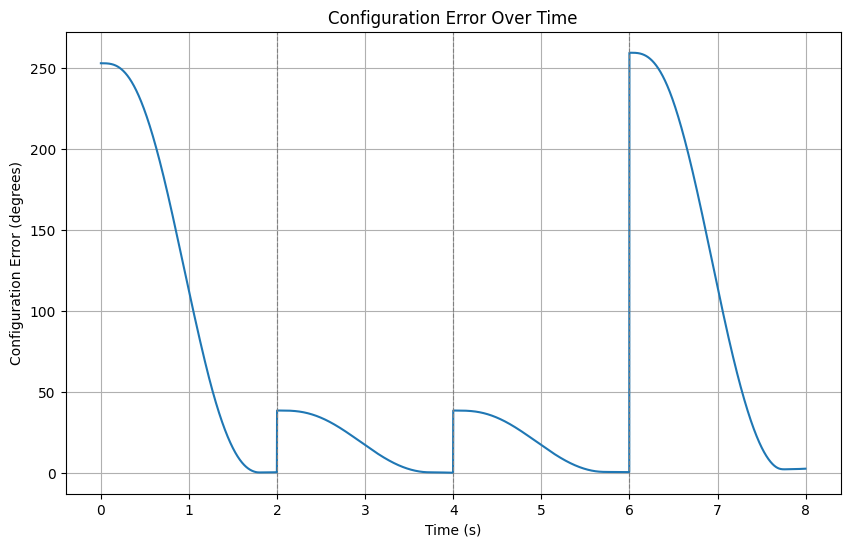

In [ ]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10, UR10_sandbox
from optimal.metrics import thermal_energy, mechanical_work, peak_power
import numpy as np

type = UR10_sandbox
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

DT = robot_mj_model.model.opt.timestep
path = [robot_pin_model.current_q(),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
     np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
     np.array([0.4, -0.4, 1.5, -0.8, 1.5, 0.5])]
controller = RobotController(robot_pin_model)
xs, us = [], []
v_start = np.zeros(len(robot_pin_model.v_indices))
start = np.concatenate([path[0], v_start])
for i in range(len(path) - 1):
    # kp = np.array([params[i]["kp_1"], params[i]["kp_2"], params[i]["kp_3"], params[i]["kp_4"], params[i]["kp_5"], params[i]["kp_6"]])
    # kd = np.array([params[i]["kd_1"], params[i]["kd_2"], params[i]["kd_3"], params[i]["kd_4"], params[i]["kd_5"], params[i]["kd_6"]])
    # kp= np.array([params[i]["kp_body"]]*3 + [params[i]["kp_wrist"]]*3)
    # kd= np.array([params[i]["kp_body"] * params[i]["body_ratio"]]*3 + [params[i]["kp_wrist"] * params[i]["wrist_ratio"]]*3)
    kp = np.array([params[i]["kp1"], params[i]["kp2"], params[i]["kp3"], params[i]["kp4"], params[i]["kp5"], params[i]["kp6"]])
    kd = np.array([params[i]["kp1"] * params[i]["ratio1"], params[i]["kp2"] * params[i]["ratio2"], params[i]["kp3"] * params[i]["ratio3"], params[i]["kp4"] * params[i]["ratio4"], params[i]["kp5"] * params[i]["ratio5"], params[i]["kp6"] * params[i]["ratio6"]])
    target = np.concatenate([path[i+1], np.zeros(len(robot_pin_model.v_indices))])
    t_xs, t_us = controller.compute_control(x_start=start, 
                                        x_goal=target, 
                                        # T=params[i]["time_limit"], DT=DT,
                                        T=1000, DT=DT,
                                        kp=kp,
                                        kd=kd,
                                        alpha=params[i]["alpha"],
                                        interpolation=params[i]["interpolation_method"],
                                        option="pd")
    start = np.concatenate([t_xs[-1][:len(robot_pin_model.q_indices)], t_xs[-1][len(robot_pin_model.q_indices):]])
    xs.extend(t_xs)
    us.extend(t_us)
    v_start = xs[-1][len(robot_pin_model.q_indices):]  # Update v_start for the next segment

# xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
# xs_real, us_real = robot_mj_model.visualize("con  trol", us=us, dt=DT, hold=False)
# xs_real, us_real = robot_mj_model.simulate_control(us=us)
# xs_real, us_real = robot_mj_model.simulate_control(us=us, xs=xs, kp=type.kp, kd=type.kd)
# xs_real, us_real = robot_mj_model.visualize("position", xs=xs, dt=DT, hold=False)
xs_real, us_real = robot_mj_model.simulate_control(us=us, xs=xs, kp=type.kp, kd=type.kd)
robot_mj_model.plot_controls(us, dt=DT)
robot_mj_model.plot_controls(us_real, dt=DT)
# lengths = [param["time_limit"] for param in params]
lengths = [1000 for _ in params]
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=lengths, dt=DT)

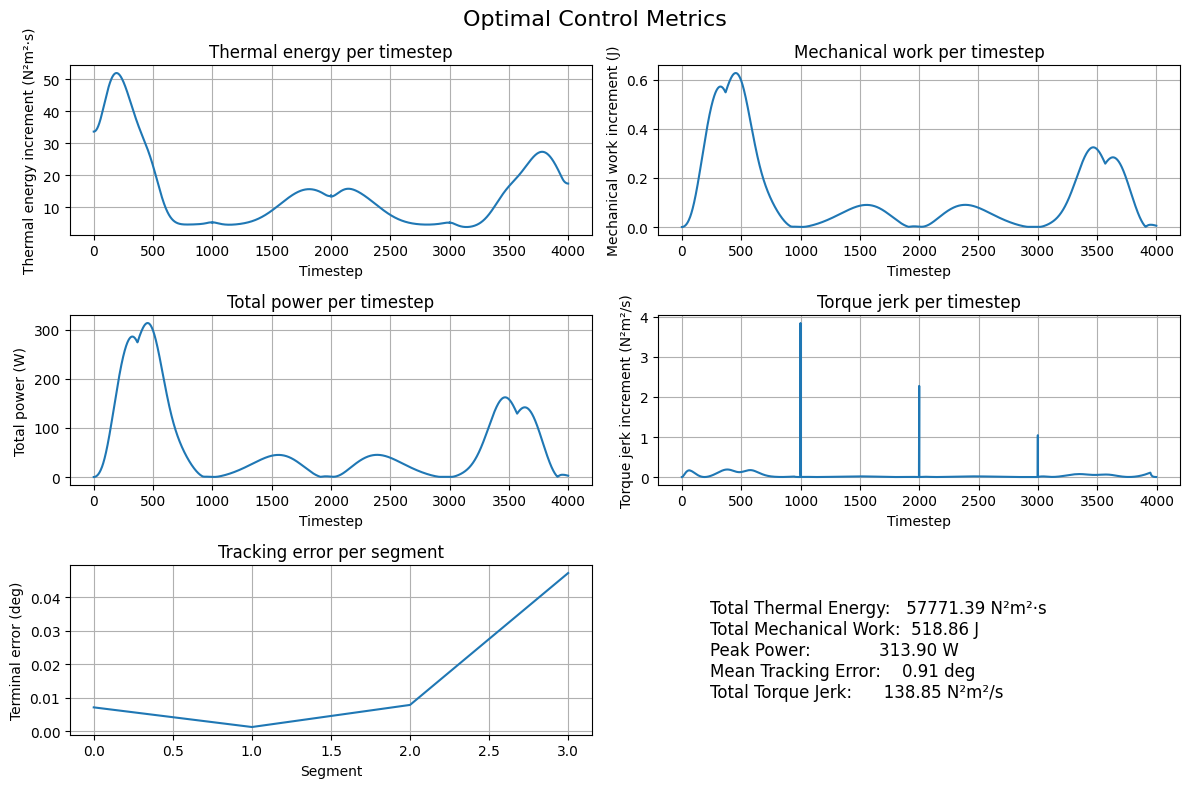

In [14]:
metrics.plot_metrics(us_real, xs_real, DT, path[1:], segment_lengths=lengths)